적률 : 그림을 수치화 해서 표현해주는 기능이다.

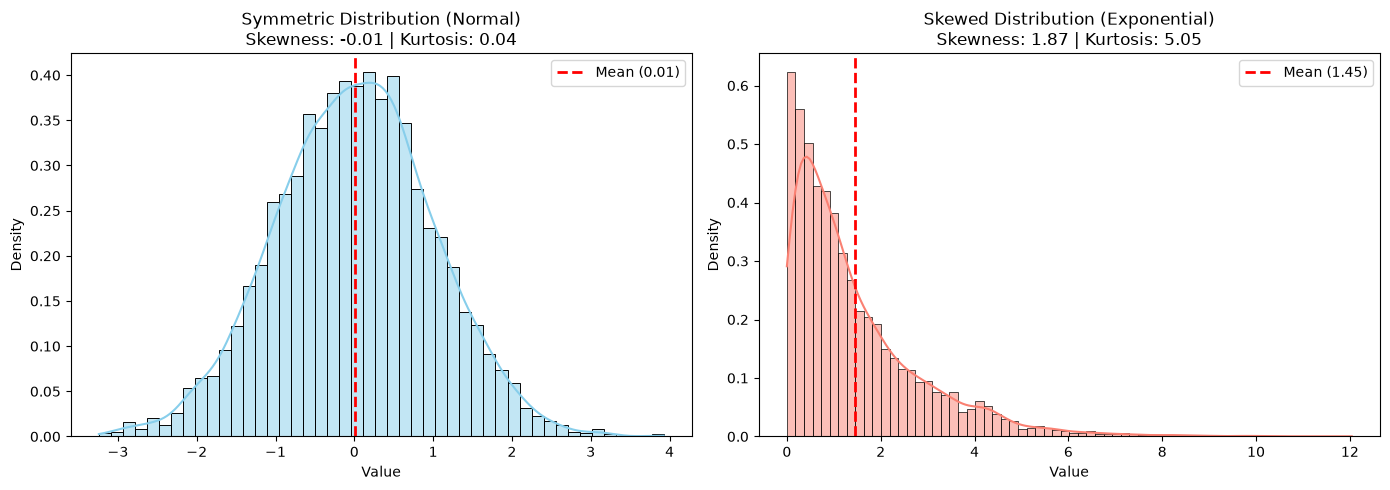

=== [대칭형 분포 (Normal)] ===
1. 평균 (Mean):     0.0056  -> 분포의 중심 위치
2. 분산 (Var):      0.9928  -> 퍼짐 정도
3. 왜도 (Skew):    -0.0119  -> 좌우 비대칭도
4. 첨도 (Kurt):     0.0402  -> 중앙의 뾰족함과 꼬리 두께

=== [비대칭형 분포 (Exponential)] ===
1. 평균 (Mean):     1.4537  -> 분포의 중심 위치
2. 분산 (Var):      2.0249  -> 퍼짐 정도
3. 왜도 (Skew):     1.8749  -> 좌우 비대칭도
4. 첨도 (Kurt):     5.0500  -> 중앙의 뾰족함과 꼬리 두께



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

################################################
# 1. 서로 다른 모양의 데이터 생성
################################################
np.random.seed(42)
normal_data = np.random.normal(loc=0, scale=1, size=5000)   # 대칭형 (정규분포)
skewed_data = np.random.exponential(scale=1.5, size=5000)  # 오른쪽 긴 꼬리형 (지수분포)

################################################
# 2. 그래프 그리기
################################################
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [왼쪽] 대칭형 분포 (정규분포)
sns.histplot(normal_data, kde=True, ax=axes[0], color='skyblue', stat="density")
axes[0].axvline(np.mean(normal_data), color='red', linestyle='--', linewidth=2, label=f'Mean ({np.mean(normal_data):.2f})')
axes[0].set_title(f"Symmetric Distribution (Normal)\nSkewness: {stats.skew(normal_data):.2f} | Kurtosis: {stats.kurtosis(normal_data):.2f}", fontsize=12)
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")
axes[0].legend()

# [오른쪽] 비대칭형 분포 (지수분포)
sns.histplot(skewed_data, kde=True, ax=axes[1], color='salmon', stat="density")
axes[1].axvline(np.mean(skewed_data), color='red', linestyle='--', linewidth=2, label=f'Mean ({np.mean(skewed_data):.2f})')
axes[1].set_title(f"Skewed Distribution (Exponential)\nSkewness: {stats.skew(skewed_data):.2f} | Kurtosis: {stats.kurtosis(skewed_data):.2f}", fontsize=12)
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

################################################
# 3. 분포의 4가지 모양 수치 계산 함수
################################################
def print_shape_metrics(data, name):
    mean = np.mean(data)           # 1차 적률: 평균 (위치)
    var = np.var(data)             # 2차 적률: 분산 (퍼짐)
    skew = stats.skew(data)        # 3차 적률: 왜도 (기울어짐)
    kurt = stats.kurtosis(data)    # 4차 적률: 첨도 (뾰족함/꼬리 두께)

    print(f"=== [{name}] ===")
    print(f"1. 평균 (Mean):   {mean:8.4f}  -> 분포의 중심 위치")
    print(f"2. 분산 (Var):    {var:8.4f}  -> 퍼짐 정도")
    print(f"3. 왜도 (Skew):   {skew:8.4f}  -> 좌우 비대칭도")
    print(f"4. 첨도 (Kurt):   {kurt:8.4f}  -> 중앙의 뾰족함과 꼬리 두께\n")

print_shape_metrics(normal_data, "대칭형 분포 (Normal)")
print_shape_metrics(skewed_data, "비대칭형 분포 (Exponential)")